In [1]:
## this code is a combination of (i) sensitivity curve generation from full and sliced datasets from Anjana and Jeremy, and (ii) single-source population manipulation from Dave.

In [1]:
import numpy as np
import json, copy
import hasasia.sensitivity as hsen
import hasasia.skymap as hsky
import hasasia.utils as hutils
import hasasia.sim as hsim
import holodeck as holo
import matplotlib.pyplot as plt
from astropy import units as utils
from astropy import constants as c
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.cm as cm
#from la_forge.utils import set_publication_params
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import holodeck as holo
from holodeck.constants import GYR, MSOL, PC, YR

import scipy.linalg as sl
import discovery as ds


# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

### Sarah's data : NG20 + a few more years of NG20-like + DSA

In [2]:
 ##get ng20 data
import glob
ng20_gwb = '/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/'
pardir = ng20_gwb
timdir = ng20_gwb
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))
#check number of pulsars
print(len(pars))
print(len(tims))

#check first par and tim files
print(pars[0])
print(tims[0])



80
80
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.par
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.tim


In [3]:
#make enterprise pulsars
from enterprise.pulsar import Pulsar as ePulsar
ePsrs = []
for par,tim in zip(pars,tims):
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/sarahspta/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.
2025-11-07 08:58:48.505 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-11-07 08:58:48.857 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-11-07 08:58:48.860 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-11-07 08:58:48.868 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 08:58:48.868 | DEBUG    | p

PSR B1855+09 complete

2025-11-07 08:58:52.079 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-11-07 08:58:52.387 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-11-07 08:58:52.390 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-11-07 08:58:52.401 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 08:58:52.402 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-11-07 08:58:52.402 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-11-07 08:58:52.519 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 08:58:52.520 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR B1937+21 complete

2025-11-07 08:58:54.256 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-11-07 08:58:54.432 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-11-07 08:58:54.437 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-11-07 08:58:54.443 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 08:58:54.444 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-11-07 08:58:54.444 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-11-07 08:58:54.497 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 08:58:54.501 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

...

PSR J2302+4442 complete

2025-11-07 09:01:10.497 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-11-07 09:01:10.789 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-11-07 09:01:10.794 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-11-07 09:01:10.808 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 09:01:10.808 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-11-07 09:01:10.809 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-11-07 09:01:10.929 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 09:01:10.931 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2317+1439 complete

2025-11-07 09:01:13.220 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2025-11-07 09:01:13.407 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-11-07 09:01:13.409 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-11-07 09:01:13.413 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 09:01:13.414 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2025-11-07 09:01:13.414 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-11-07 09:01:13.459 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-11-07 09:01:13.460 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2322+2057 complete

In [4]:
Tspan = hsen.get_Tspan(ePsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)
#freqs = np.logspace(np.log10(1/(T5span)),np.log10(2e-7),600)

In [5]:
def make_corr(psr,noise):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    for ky in keys:
        if ky.endswith('_log10_t2equad'):
            new_key = ky.replace('_log10_t2equad', '_log10_equad')
            noise[new_key] = noise[ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        sigma_sqr[mask] = (noise[key_ef]**2 * ((psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2))
        #mask_ec = np.where(fl==be)
        #key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        #ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    #j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
        # for ii, bucket in enumerate(bi)]

    #J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) #+ J
    return corr

In [6]:
#sarah's noise file
sarahs_noise_file = '/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'
import json
with open(sarahs_noise_file,'r') as f:
    noise = json.load(f)
rn_psrs = noise
#print(rn_psrs)

#Nihan's noise dict for 15yr 
nihans_dict = '/Users/ashokan/osu/sarahspta/15yr_v1_fl_fwn_dict.json'
with open(nihans_dict,'r') as f:
    nihans_noise = json.load(f)

#NG20 real noise dict
ng20_noise_dict = '/Users/ashokan/osu/sarahspta/ng20_v1p1_dmx_noise_dict.json'
#from https://drive.google.com/drive/folders/1GQXnpyRglqPHwgQs6vE8VK-6VoL9WbSj
with open(ng20_noise_dict,'r') as f:
    ng20_noise_real = json.load(f)

#make a new noise dict with only chime and vegas pulsars
chime_vegas_noise_dict = {}
for k, v in ng20_noise_real.items():
    new_key = k.replace("t2equad", "equad")
    if "CHIME" in k or "YUPPI" in k or "VEGAS" in k or "J0125-2327" in k or "J0154+1833" in k or "J0614-3329" in k or "J0621+2514" in k or "J0732+2314" in k or "J0751+1807" in k or "J1022+1001" in k or "J1803+1358" in k or "J2022+2534" in k or "J2039-3616" in k or "J2150-0326" in k:
        print(k)
        chime_vegas_noise_dict[new_key] = v

#update nihans noise dict with chime and vegas pulsars from ng20
nihans_noise.update(chime_vegas_noise_dict)

#dsa noise dict
dsa_noise_dict = '/Users/ashokan/osu/sarahspta/data/dsa_wn_dict.json'
with open(dsa_noise_dict,'r') as f:
    dsa_noise = json.load(f)

#combine nihans noise dict with dsa noise dict
#nihans_noise_copy = nihans_noise.copy()

B1855+09_CHIME_efac
B1855+09_CHIME_log10_ecorr
B1855+09_CHIME_log10_t2equad
B1855+09_Rcvr1_2_VEGAS_efac
B1855+09_Rcvr1_2_VEGAS_log10_ecorr
B1855+09_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_3GHz_YUPPI_efac
B1937+21_3GHz_YUPPI_log10_ecorr
B1937+21_3GHz_YUPPI_log10_t2equad
B1937+21_CHIME_efac
B1937+21_CHIME_log10_ecorr
B1937+21_CHIME_log10_t2equad
B1937+21_Rcvr1_2_VEGAS_efac
B1937+21_Rcvr1_2_VEGAS_log10_ecorr
B1937+21_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_Rcvr_800_VEGAS_efac
B1937+21_Rcvr_800_VEGAS_log10_ecorr
B1937+21_Rcvr_800_VEGAS_log10_t2equad
B1953+29_CHIME_efac
B1953+29_CHIME_log10_ecorr
B1953+29_CHIME_log10_t2equad
J0023+0923_CHIME_efac
J0023+0923_CHIME_log10_ecorr
J0023+0923_CHIME_log10_t2equad
J0023+0923_Rcvr1_2_VEGAS_efac
J0023+0923_Rcvr1_2_VEGAS_log10_ecorr
J0023+0923_Rcvr1_2_VEGAS_log10_t2equad
J0030+0451_CHIME_efac
J0030+0451_CHIME_log10_ecorr
J0030+0451_CHIME_log10_t2equad
J0030+0451_Rcvr1_2_VEGAS_efac
J0030+0451_Rcvr1_2_VEGAS_log10_ecorr
J0030+0451_Rcvr1_2_VEGAS_log10_t2equad
J0

In [7]:
len(nihans_noise)

1364

In [8]:
nihans_noise.update(dsa_noise)
len(nihans_noise)

1664

In [9]:
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in ePsrs:
    #corr = make_corr_our(ePsr)[::thin,::thin]
    nihans_corr = make_corr(ePsr,nihans_noise)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                               toas=ePsr.toas[:])
    psr = hsen.Pulsar(toas=ePsr.toas[:],
                      toaerrs=ePsr.toaerrs[:],
                      phi=ePsr.phi,theta=ePsr.theta,
                      N=nihans_corr, designmatrix=ePsr.Mmat[:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

PSR J2322+2057 complete

In [10]:
#make spectra
#make spectra
specs = []
for p in psrs:
    print(p.name)
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)
ng20_sens = hsen.GWBSensitivityCurve(specs)

B1855+09
PSR B1855+09 completeB1937+21
PSR B1937+21 completeB1953+29
PSR B1953+29 completeJ0023+0923
PSR J0023+0923 completeJ0030+0451
PSR J0030+0451 completeJ0102+4839
PSR J0102+4839 completeJ0125-2327
PSR J0125-2327 completeJ0154+1833
PSR J0154+1833 completeJ0218+4232
PSR J0218+4232 completeJ0340+4130
PSR J0340+4130 completeJ0406+3039
PSR J0406+3039 completeJ0437-4715
PSR J0437-4715 completeJ0509+0856
PSR J0509+0856 completeJ0557+1551
PSR J0557+1551 completeJ0605+3757
PSR J0605+3757 completeJ0610-2100
PSR J0610-2100 completeJ0613-0200
PSR J0613-0200 completeJ0614-3329
PSR J0614-3329 completeJ0621+2514
PSR J0621+2514 completeJ0636+5128
PSR J0636+5128 completeJ0645+5158
PSR J0645+5158 completeJ0709+0458
PSR J0709+0458 completeJ0732+2314
PSR J0732+2314 completeJ0740+6620
PSR J0740+6620 completeJ0751+1807
PSR J0751+1807 completeJ0931-1902
PSR J0931-1902 completeJ1012+5307
PSR J1012+5307 completeJ1012-4235
PSR J1012-4235 completeJ1022+1001
PSR J1022+1001 completeJ1024-0719
PSR J1024-0719 

In [155]:
hsky.SkySensitivity??

Init signature:
hsky.SkySensitivity(
    spectra,
    theta_gw,
    phi_gw,
    pulsar_term=False,
    pol='gr',
    iota=None,
    psi=None,
)
Source:        
class SkySensitivity(DeterSensitivityCurve):
    r'''
    Class to make sky maps for deterministic PTA gravitational wave signals.
    Calculated in terms of :math:`\hat{n}=-\hat{k}`.

    Parameters
    ----------
    theta_gw : list, array
        Gravitational wave source sky location colatitude at which to
        calculate sky map.

    phi_gw : list, array
        Gravitational wave source sky location longitude at which to
        calculate sky map.

    pulsar_term : bool, str, optional [True, False, 'explicit']
        Flag for including the pulsar term in sky map sensitivity. True
        includes an idealized factor of two from Equation (36) of `[1]`_.
        The `'explicit'` flag turns on an explicit calculation of
        pulsar terms using pulsar distances. (This option takes
        considerably more computationa

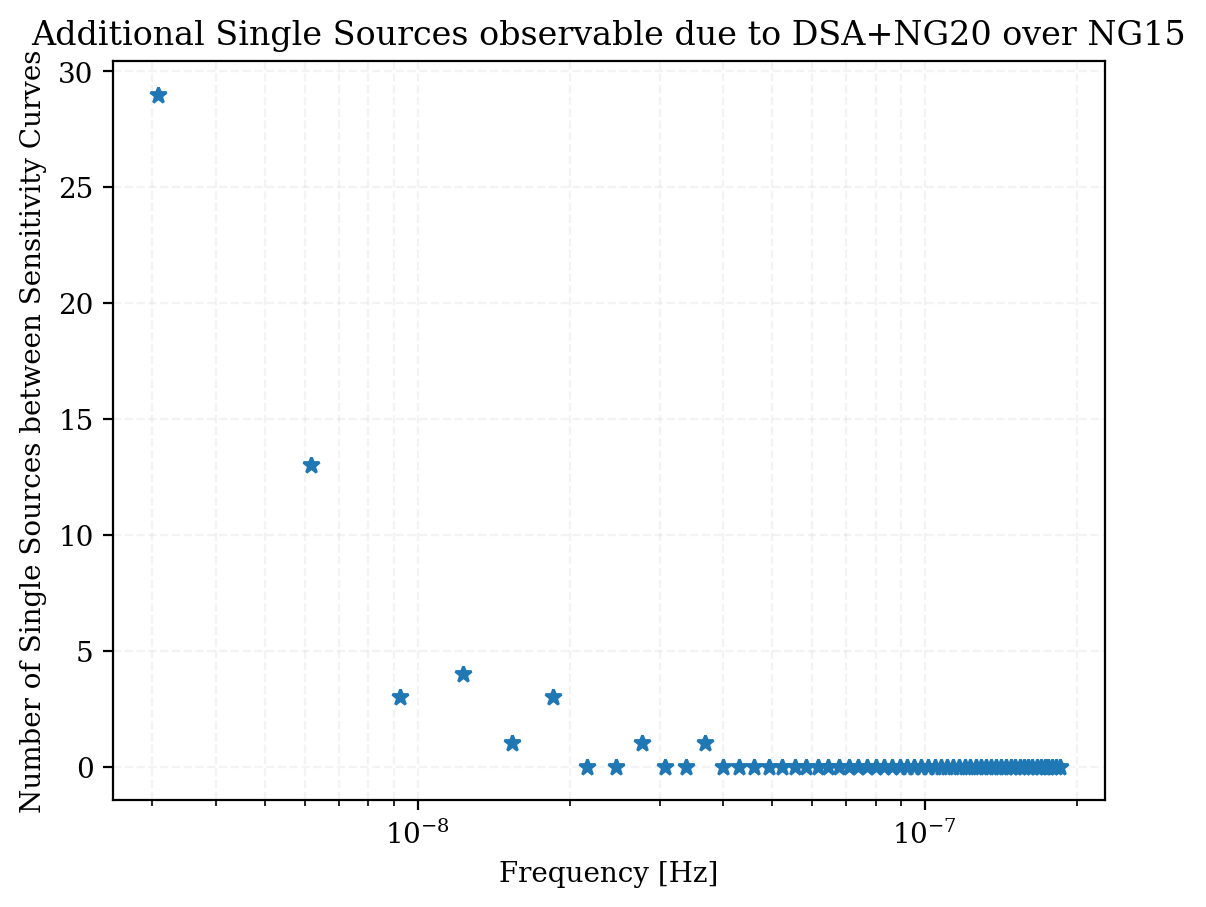

In [ ]:

upper_curve = hc_sliced_at_fobs_gw
lower_curve = hc_full_at_fobs_gw

#plt.plot(hc_ss[:,0,1,0])
# # hc_ss shape: (nr, freq, rr, ll)
count_fi = []
for fi in range(len(fobs_gw_cents)):
    count_reals = 0
    for rr in range(nreals):
        #print(len(hc_ss[1:10, fi, rr, 0]))
        this_real = len(np.where((hc_ss[:plot_num_params, fi, rr, 0]*span_factor > lower_curve[fi]) & (hc_ss[:plot_num_params, fi, rr, 0]*span_factor < upper_curve[fi]))[0])
        #print(f"fi={fi}, rr={rr}, this_real={this_real}")
        count_reals += this_real    
    count_fi.append(count_reals)

# ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
# ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

plt.plot(fobs_gw_cents,count_fi,'*')
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Number of Single Sources between Sensitivity Curves')
plt.title('Additional Single Sources observable due to DSA+NG20 over NG15')
plt.grid(which='both', ls='--')
plt.savefig("num_additional_ss_dsa_ng20_over_ng15.png", dpi=300)#, bbox_inches='tight')
plt.show()   

In [11]:
alpha_gwb = (3. - gamma_gwb) / 2.
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20 = ng20_sens.SNR(S_h)
print(snr_20)

14.478280896312938


In [12]:
#slice
def get_sliced_spectra(psrs, freqs,
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p,freqs=freqs,amp_gw=None, gamma_gw=None)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs and tspan {timespan/365.25/24/3600:.1f} created.")
    return spectra

In [13]:
end_mjd = 59033
psr_spectra = get_sliced_spectra(psrs, freqs,
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

PTA spectrum with 67 psrs and tspan 15.9 created.


In [14]:
sliced_GWBSC = hsen.GWBSensitivityCurve(spectra=psr_spectra, orf='hd', autocorr=False)
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
sliced_SNR = sliced_GWBSC.SNR(S_h)
print(sliced_SNR)

5.633745561160936


### 0) Realistic SNR from this sensitivity curve for bins of 1/T, 2/T .. 30/T

In [15]:
def SNR_chunky(S_eff, Sh, freqs, Tspan):
        """
        Calculate the signal-to-noise ratio of a given signal strain power
        spectral density, `Sh`. Calculate the SNR over the specificied frequencies.
        """
        integrand = Sh**2 / S_eff**2
        SNR = np.sqrt(2.0 * Tspan * np.trapezoid(y=integrand,
                                                   x=freqs,
                                                   axis=0))
        return SNR, freqs, integrand

In [16]:
#full 20 year
Tspan_20 = hsen.get_Tspan(specs)
print('Tspan_20:', Tspan_20/(365*86400))
freqs_20 = np.linspace(1/Tspan_20, 30/Tspan_20, 30)
ng20_mask = np.array([np.argmin(np.abs(freqs - f20)) for f20 in freqs_20])
print('freqs_20:', freqs[ng20_mask])
print('len(freqs_20):', len(freqs[ng20_mask]))
S_h_20 = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs_20)
snr_20_chunky, freqs_20, integrand_20 = SNR_chunky(ng20_sens.S_eff[ng20_mask], S_h_20, freqs_20, Tspan_20)
print('snr_20_chunky:', snr_20_chunky)

Tspan_20: 25.439316406405197
freqs_20: [1.24427538e-09 2.48616400e-09 3.75775112e-09 4.96755907e-09
 6.21033548e-09 7.50829417e-09 8.68106671e-09 9.92558942e-09
 1.12225337e-08 1.24087584e-08 1.37203673e-08 1.50021860e-08
 1.62216398e-08 1.75402170e-08 1.87554102e-08 2.00547926e-08
 2.12061183e-08 2.24235405e-08 2.37108537e-08 2.47937144e-08
 2.62170969e-08 2.74144164e-08 2.86664166e-08 2.99755950e-08
 3.09965684e-08 3.24121635e-08 3.35161267e-08 3.50467885e-08
 3.62404875e-08 3.74748441e-08]
len(freqs_20): 30
snr_20_chunky: 14.101497046718922


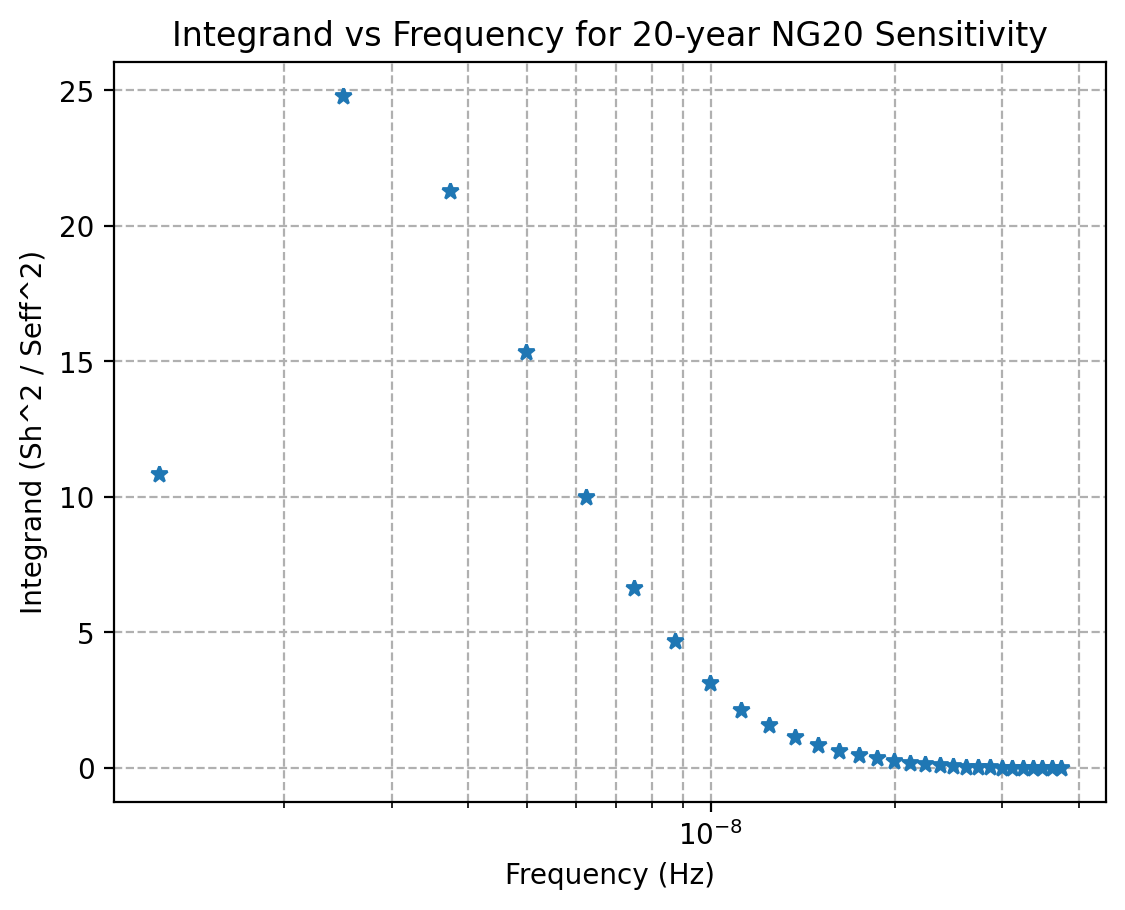

In [17]:
plt.plot(freqs_20, integrand_20,'*')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.grid(which='both', ls='--')
plt.show()

In [18]:
#15year slice
Tspan_15 = 502576288.3556185 #found from doing hsen.get_Tspan(psr_spectra) on a sliced spectra
print('Tspan_15:', Tspan_15/(365*86400))
freqs_15 = np.linspace(1/Tspan_15, 30/Tspan_15, 30)
ng15_mask = np.array([np.argmin(np.abs(freqs - f15)) for f15 in freqs_15])
print('freqs_15:', freqs[ng15_mask])
print('len(freqs_15):', len(freqs[ng15_mask]))
S_h_15 = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs_15)
snr_15_chunky = SNR_chunky(sliced_GWBSC.S_eff[ng15_mask], S_h_15, freqs_15, Tspan_15)
print('snr_15_chunky:', snr_15_chunky)


Tspan_15: 15.93658955972915
freqs_15: [1.98864724e-09 3.97347988e-09 5.93910026e-09 7.93933788e-09
 9.92558942e-09 1.20000353e-08 1.38744041e-08 1.58634466e-08
 1.79362713e-08 1.98321397e-08 2.19284019e-08 2.39770523e-08
 2.59260288e-08 2.77221944e-08 2.99755950e-08 3.16964642e-08
 3.38924079e-08 3.58381374e-08 3.78955693e-08 3.96262376e-08
 4.19011406e-08 4.38147411e-08 4.58157345e-08 4.79081122e-08
 4.95398699e-08 5.18023266e-08 5.35667218e-08 5.60130825e-08
 5.79208966e-08 5.98936913e-08]
len(freqs_15): 30
snr_15_chunky: (np.float64(5.413011305731731), array([1.98974767e-09, 3.97949534e-09, 5.96924302e-09, 7.95899069e-09,
       9.94873836e-09, 1.19384860e-08, 1.39282337e-08, 1.59179814e-08,
       1.79077291e-08, 1.98974767e-08, 2.18872244e-08, 2.38769721e-08,
       2.58667197e-08, 2.78564674e-08, 2.98462151e-08, 3.18359628e-08,
       3.38257104e-08, 3.58154581e-08, 3.78052058e-08, 3.97949534e-08,
       4.17847011e-08, 4.37744488e-08, 4.57641965e-08, 4.77539441e-08,
       4.974

In [19]:
#lets get the continuous frequency integrand 
def SNR(sc, Sh):
    """
    Calculate the signal-to-noise ratio of a given signal strain power
    spectral density, `Sh`. Must match frequency range and `df` of
    `self`.
    """
    integrand = Sh**2 / sc.S_eff**2
    SNR = np.sqrt(2.0 * sc.Tspan * np.trapezoid(y=integrand,
                                                x=sc.freqs,
                                                axis=0))
    return SNR, sc.freqs, integrand

14.478280896312938


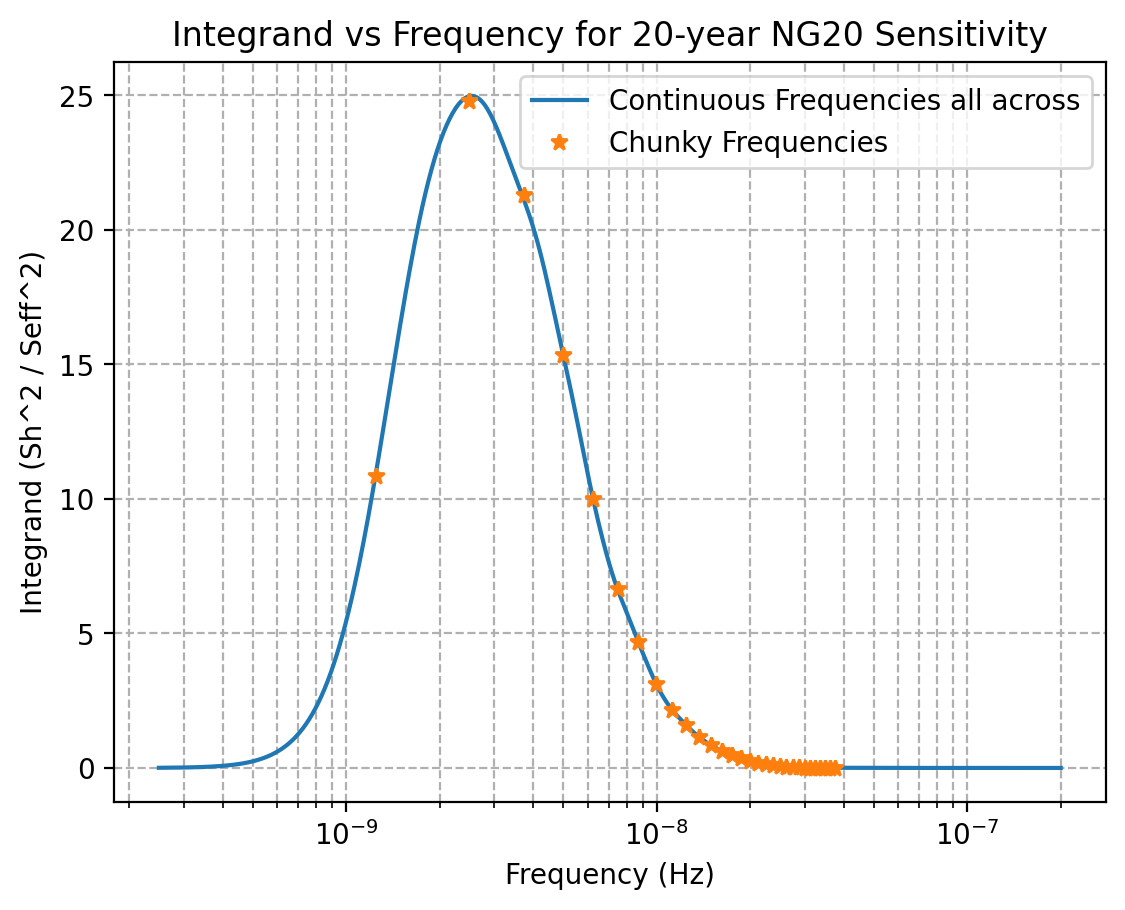

In [20]:
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20,freqs_cont, integrand_cont = SNR(ng20_sens,S_h)
print(snr_20)
plt.plot(freqs_cont, integrand_cont,label='Continuous Frequencies all across')
plt.plot(freqs_20, integrand_20,'*',label='Chunky Frequencies')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.grid(which='both', ls='--')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.legend()
plt.show()

14.478280896312938


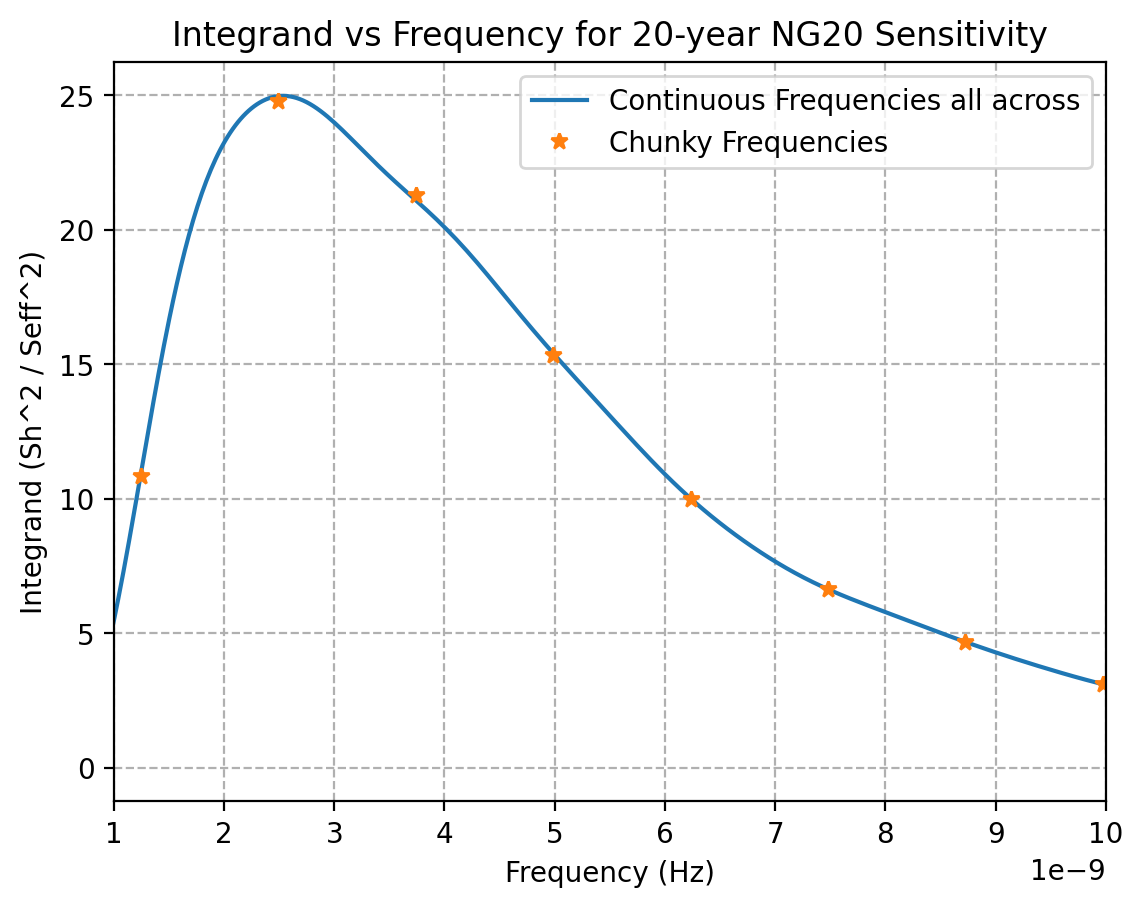

In [21]:
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20,freqs_cont, integrand_cont = SNR(ng20_sens,S_h)
print(snr_20)
plt.plot(freqs_cont, integrand_cont,label='Continuous Frequencies all across')
plt.plot(freqs_20, integrand_20,'*',label='Chunky Frequencies')
#plt.xscale('log')
plt.xlim(1e-9, 1e-8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Integrand (Sh^2 / Seff^2)')
plt.grid(which='both', ls='--')
plt.title('Integrand vs Frequency for 20-year NG20 Sensitivity')
plt.legend()
plt.show()

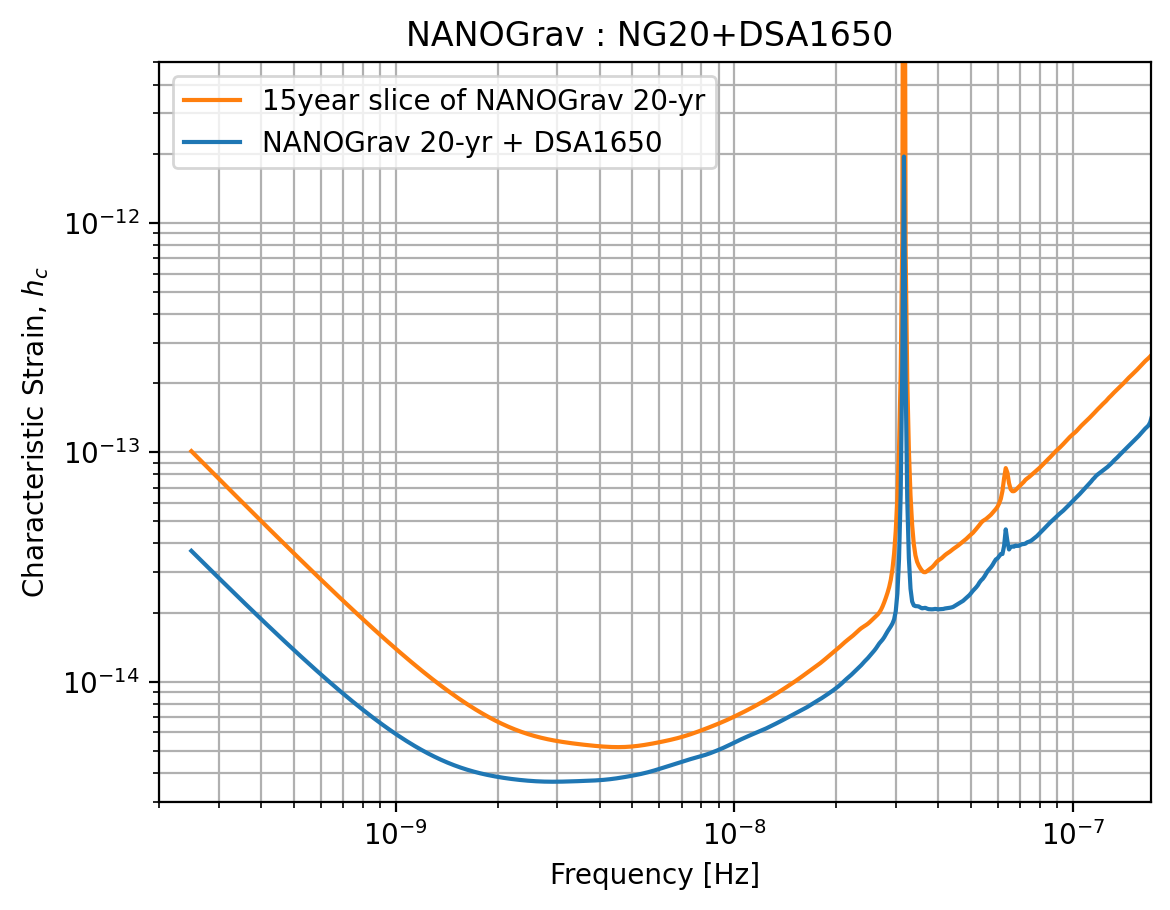

In [22]:
#plot 15year slice of NG20 against NG15

plt.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
plt.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr + DSA1650')



plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav : NG20+DSA1650 ')#, SNR={:.1f}'.format(
 #   sliced_SNR
#)


#plt.title('NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}'.format(FACTOR),'SNR={:.2f}'.format(sliced_with_factor_SNR))

plt.grid(which='both')
plt.ylim(3e-15,5e-12)
plt.xlim(2e-10,1.7e-7)
plt.legend()
plt.savefig("ng15_dsa_sensitivity_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## 1) Sensitivity comparison between NG15 and NG20 for GWB

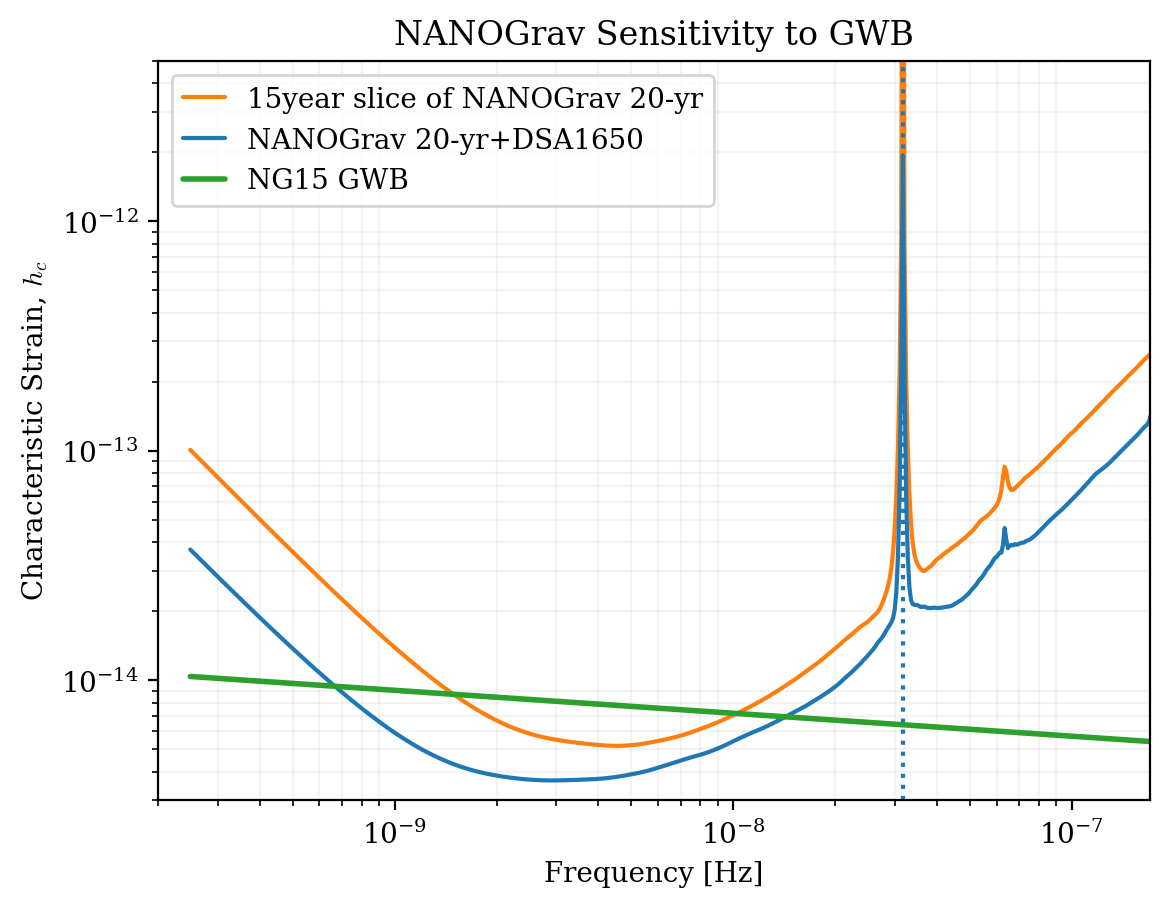

In [ ]:
h = 6.4e-15
gamma_gwb = 3.2
alpha_gwb = (3. - gamma_gwb) / 2. 
plaw = np.dot((ng20_sens.freqs[:]/fyr)**alpha_gwb,
              h)
import pickle
ng15_pkl_gwb = '/Users/ashokan/osu/sarahspta/ng15yr_v1p1_pint_logf_m2a_red_noise_vg_gwbsc.has' 
with open (ng15_pkl_gwb,'rb') as f:
    ng15_sc_gwb = pickle.load(f)

#plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
plt.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
plt.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr+DSA1650')
plt.loglog(ng20_sens.freqs,plaw,lw=2,color='C2',label='NG15 GWB')

plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.axvline(fyr,linestyle=':')
plt.rc('text', usetex=False)
plt.title('NANOGrav Sensitivity to GWB')
plt.ylim(3e-15,5e-12)
plt.xlim(2e-10,1.7e-7)
# plt.text(x=4e-8,y=3e-15,
#          s=r'$A_{\rm GWB}$='+'{0:1.2e}'.format(hgw),
#          bbox=dict(facecolor='white', alpha=0.6))
plt.grid(which='both')
plt.legend(loc='upper left')
plt.savefig("dsa_ng20_ng15_sensitivity_comparison_gwb.png", dpi=300, bbox_inches='tight')
plt.show()

## 2) Sensitivity comparison between NG15 and NG20 for CWs

### Dave's single source population

In [24]:
import h5py
data = h5py.File('pop-draw-sims.h5', 'r') 

In [25]:
data.keys()

<KeysViewHDF5 ['fobs_orb_edges', 'gsmf_mchar0_log10', 'gsmf_phi0', 'hard_gamma_inner', 'hard_time', 'hc_bg', 'hc_ss', 'mmb_mamp_log10', 'mmb_scatter_dex']>

In [26]:
len(data['hc_bg']), len(data['hc_ss']),len(data["fobs_orb_edges"])

(100, 100, 100)

In [27]:
print(data["fobs_orb_edges"][0])

[7.69128345e-10 2.30738504e-09 3.84564173e-09 5.38389842e-09
 6.92215511e-09 8.46041180e-09 9.99866849e-09 1.15369252e-08
 1.30751819e-08 1.46134386e-08 1.61516952e-08 1.76899519e-08
 1.92282086e-08 2.07664653e-08 2.23047220e-08 2.38429787e-08
 2.53812354e-08 2.69194921e-08 2.84577488e-08 2.99960055e-08
 3.15342621e-08 3.30725188e-08 3.46107755e-08 3.61490322e-08
 3.76872889e-08 3.92255456e-08 4.07638023e-08 4.23020590e-08
 4.38403157e-08 4.53785724e-08 4.69168290e-08 4.84550857e-08
 4.99933424e-08 5.15315991e-08 5.30698558e-08 5.46081125e-08
 5.61463692e-08 5.76846259e-08 5.92228826e-08 6.07611393e-08
 6.22993959e-08 6.38376526e-08 6.53759093e-08 6.69141660e-08
 6.84524227e-08 6.99906794e-08 7.15289361e-08 7.30671928e-08
 7.46054495e-08 7.61437062e-08 7.76819628e-08 7.92202195e-08
 8.07584762e-08 8.22967329e-08 8.38349896e-08 8.53732463e-08
 8.69115030e-08 8.84497597e-08 8.99880164e-08 9.15262731e-08
 9.30645297e-08]


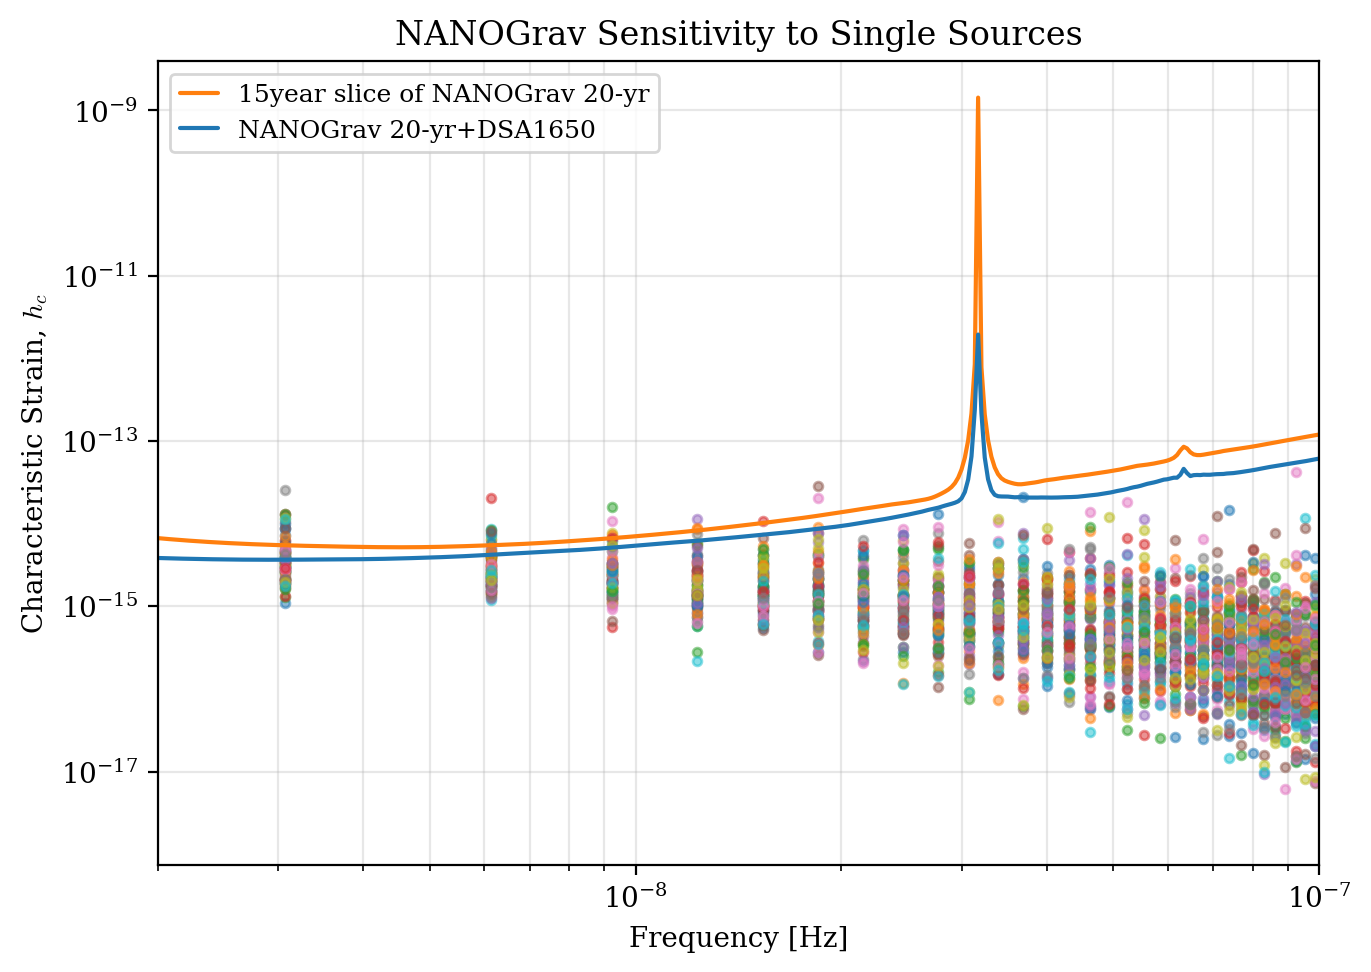

In [28]:
from holodeck import cosmo, plot, utils
from holodeck.constants import GYR, MSOL, PC, YR
from holodeck.librarian import posterior_populations as postpop
# Number of realizations to plot
plot_num_reals = 10
plot_num_params = 10
# Number of loudest-binaries-per-bin to plot
plot_num_loudest = 1

# ---- Load data

# Frequency bin edges, in units of [1/sec], for orbital frequencies
fobs_orb_edges = data["fobs_orb_edges"][0]  # Just need the first one, they're all the same
# convert to GW frequency centers (assuming circular orbits)
fobs_orb_cents = 0.5 * (fobs_orb_edges[1:] + fobs_orb_edges[:-1])
fobs_gw_cents = 2.0 * fobs_orb_cents #* YR

# Characteristic strains of the L loudest binaries in each of F frequency bins for each of R realizations
# shape: (NParReals, F, R, L)
hc_ss = data["hc_ss"]
npar_reals, nfreqs, nreals, nloudest = hc_ss.shape 
# Characteristic strain of all *other* binaries (i.e. All minus L)
# shape: (NParReals, F, R)
hc_bg = data["hc_bg"]

# can't plot more elements than we have in the data
plot_num_reals = np.minimum(plot_num_reals, nreals)
plot_num_params = np.minimum(plot_num_params, npar_reals)
plot_num_loudest = np.minimum(plot_num_loudest, nloudest)

# ---- Plot GW signals

fig, ax = holo.plot.figax()
for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # this is the combined GWs from all binaries except `L` loudest in each frequency bin
        bg = hc_bg[nr, :, rr]
        # add back in the strains from the loudest binaries that we aren't plotting
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            # Add in quadrature, summing over however many loudest binaries remain
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
         
        #(hh,) = ax.plot(fobs_gw_cents, bg, alpha=0.75)
        for ll in range(plot_num_loudest):
            ax.scatter(
                fobs_gw_cents, hc_ss[nr, :, rr, ll], s=10, alpha=0.5
            )
            
# Plot a -2/3 power-law of amplitude 1e-15 for reference
#hc_plaw = 1.0e-15 * np.power(fobs_gw_cents, -2.0 / 3.0)
#ax.plot(fobs_gw_cents, hc_plaw, "k--", alpha=0.5, lw=1.0)

#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
ax.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr+DSA1650')
#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlim(2e-9,1e-7)
# ---- Labels, legend, and grid
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title(
    'NANOGrav Sensitivity to Single Sources'#\n'
    #f'SNR={sliced_SNR:.2f}'
)
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
plt.tight_layout()
#plt.show()
plt.savefig("dsa_ng20_ng15_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()

#### In a color scheme that matches the GWB version

60


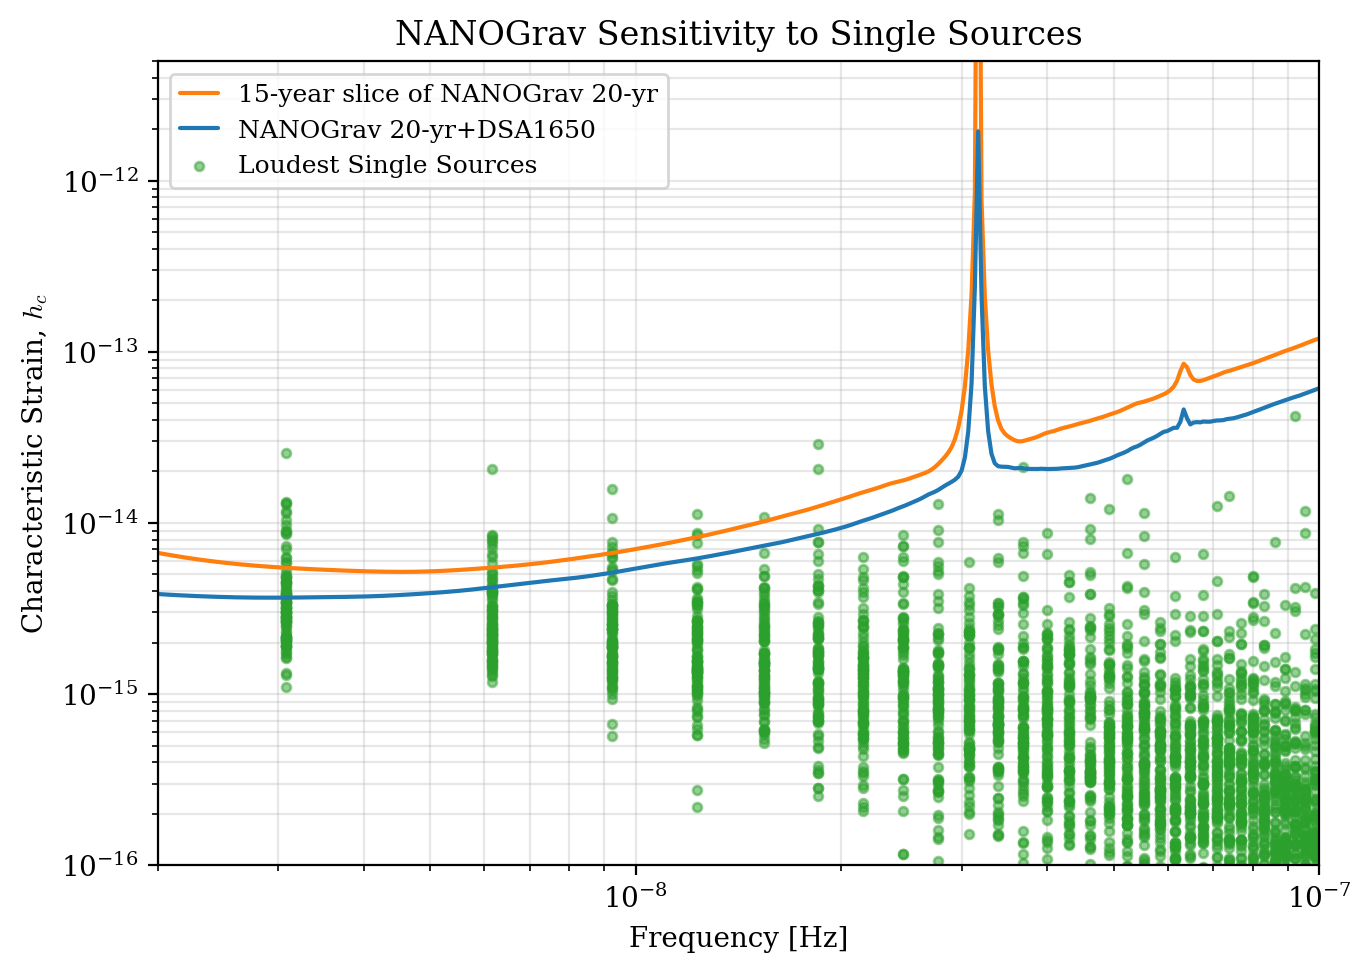

In [137]:
fig, ax = holo.plot.figax()
span_factor = np.sqrt(Tspan_20/Tspan_15) #from Dave's calculation on the board

# Sensiticity curves
#ax.loglog(ng15_sc_gwb.freqs, ng15_sc_gwb.h_c, color='C3', label='Original NG15')
ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

# Flag to only label the single-source scatter once
labeled_single_sources = False
single_source_color = 'C2'  # choose any matplotlib color (C0–C9, or 'gray', etc.)

for nr in range(plot_num_params): #10
    for rr in range(plot_num_reals): #10
        # Combined GWs from all binaries except `L` loudest
        bg = hc_bg[nr, :, rr]

        # Add in remaining loudest binaries (if any)
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:] 
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
        #full hc_ss = (100, 60, 10, 1)
        # Plot the single sources (same color for all)
        for ll in range(plot_num_loudest): #1
            if not labeled_single_sources:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll]*span_factor, #[10,:,10,1]
                    s=10,
                    alpha=0.5,
                    color=single_source_color,
                    label='Loudest Single Sources'
                )
                print(len(hc_ss[nr, :, rr, ll]))
                labeled_single_sources = True
            else:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color
                )


# Axis setup and labels
plt.xlim(2e-9, 1e-7)
plt.ylim(1e-16,5e-12)
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title('NANOGrav Sensitivity to Single Sources')
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("dsa_ng20_ng15_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()


# 2.1 ) Number of extra sources in DSA across frequency

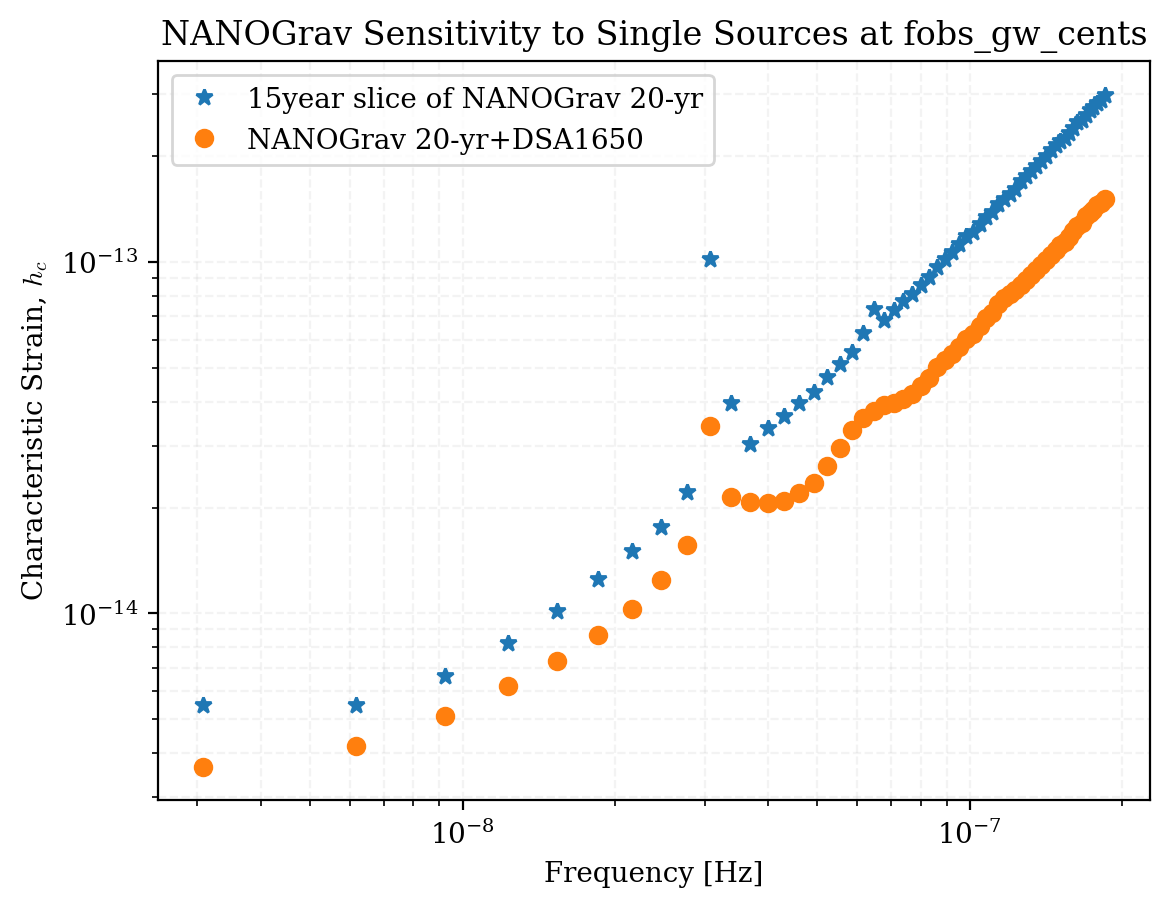

In [54]:
indices_sliced = []
for f in fobs_gw_cents:
    #print(f)
    ind = np.argmin(np.abs(sliced_GWBSC.freqs - f))
    indices_sliced.append(ind)
len(indices_sliced)

indices_full= []
for f in fobs_gw_cents:
    #print(f)
    ind = np.argmin(np.abs(ng20_sens.freqs - f))
    indices_full.append(ind)
len(indices_full)


hc_sliced_at_fobs_gw = sliced_GWBSC.h_c[indices_sliced]
hc_full_at_fobs_gw = ng20_sens.h_c[indices_full]

plt.plot(fobs_gw_cents,hc_sliced_at_fobs_gw,'*',label='15year slice of NANOGrav 20-yr')
plt.plot(fobs_gw_cents,hc_full_at_fobs_gw,'o',label='NANOGrav 20-yr+DSA1650')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav Sensitivity to Single Sources at fobs_gw_cents')
plt.grid(which='both', ls='--')
plt.legend()
plt.show()

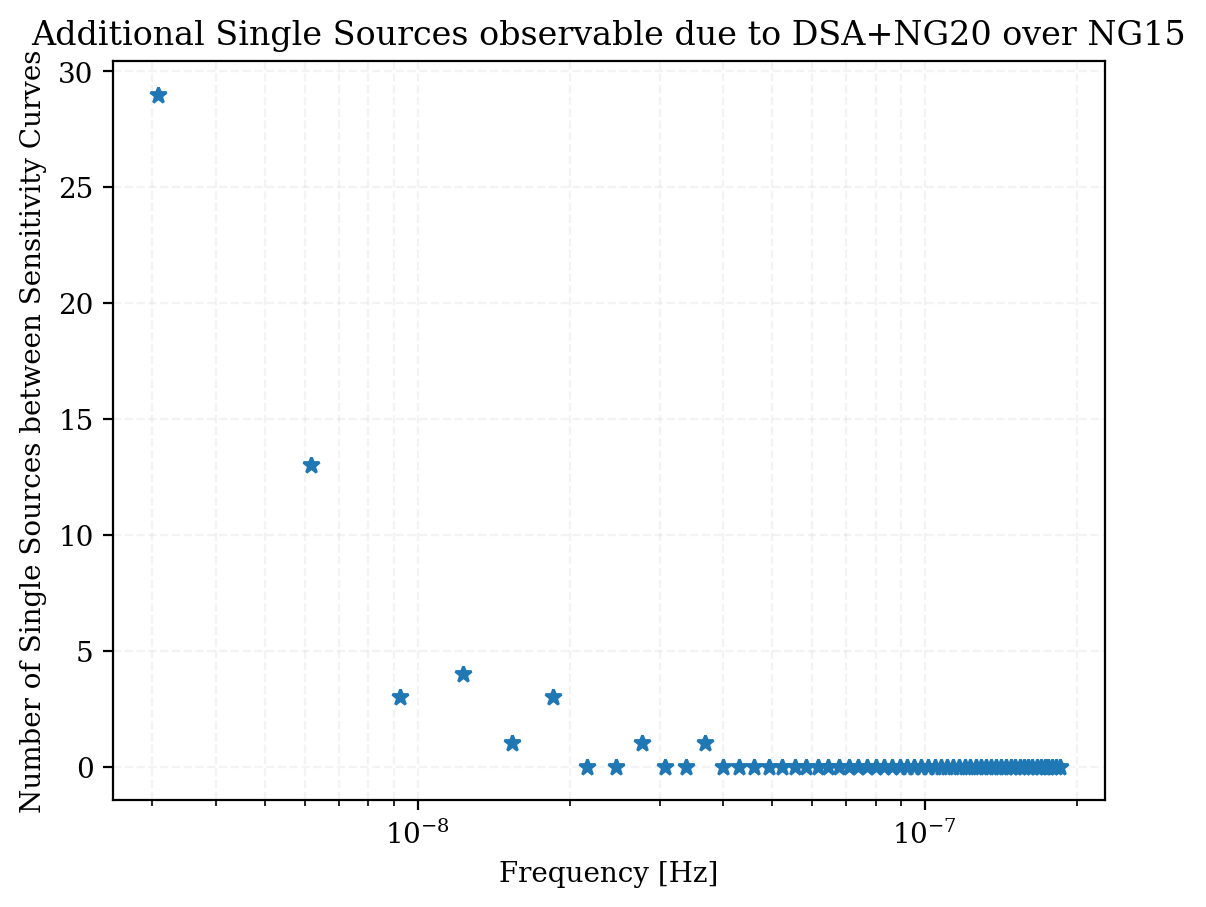

In [138]:

upper_curve = hc_sliced_at_fobs_gw
lower_curve = hc_full_at_fobs_gw

#plt.plot(hc_ss[:,0,1,0])
# # hc_ss shape: (nr, freq, rr, ll)
count_fi = []
for fi in range(len(fobs_gw_cents)):
    count_reals = 0
    for rr in range(nreals):
        #print(len(hc_ss[1:10, fi, rr, 0]))
        this_real = len(np.where((hc_ss[:plot_num_params, fi, rr, 0]*span_factor > lower_curve[fi]) & (hc_ss[:plot_num_params, fi, rr, 0]*span_factor < upper_curve[fi]))[0])
        #print(f"fi={fi}, rr={rr}, this_real={this_real}")
        count_reals += this_real    
    count_fi.append(count_reals)

# ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
# ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

plt.plot(fobs_gw_cents,count_fi,'*')
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Number of Single Sources between Sensitivity Curves')
plt.title('Additional Single Sources observable due to DSA+NG20 over NG15')
plt.grid(which='both', ls='--')
plt.savefig("num_additional_ss_dsa_ng20_over_ng15.png", dpi=300)#, bbox_inches='tight')
plt.show()   

In [98]:
print(hc_ss.shape)
print(lower_curve.shape)
print(upper_curve.shape)

(100, 60, 10, 1)
(60,)
(60,)


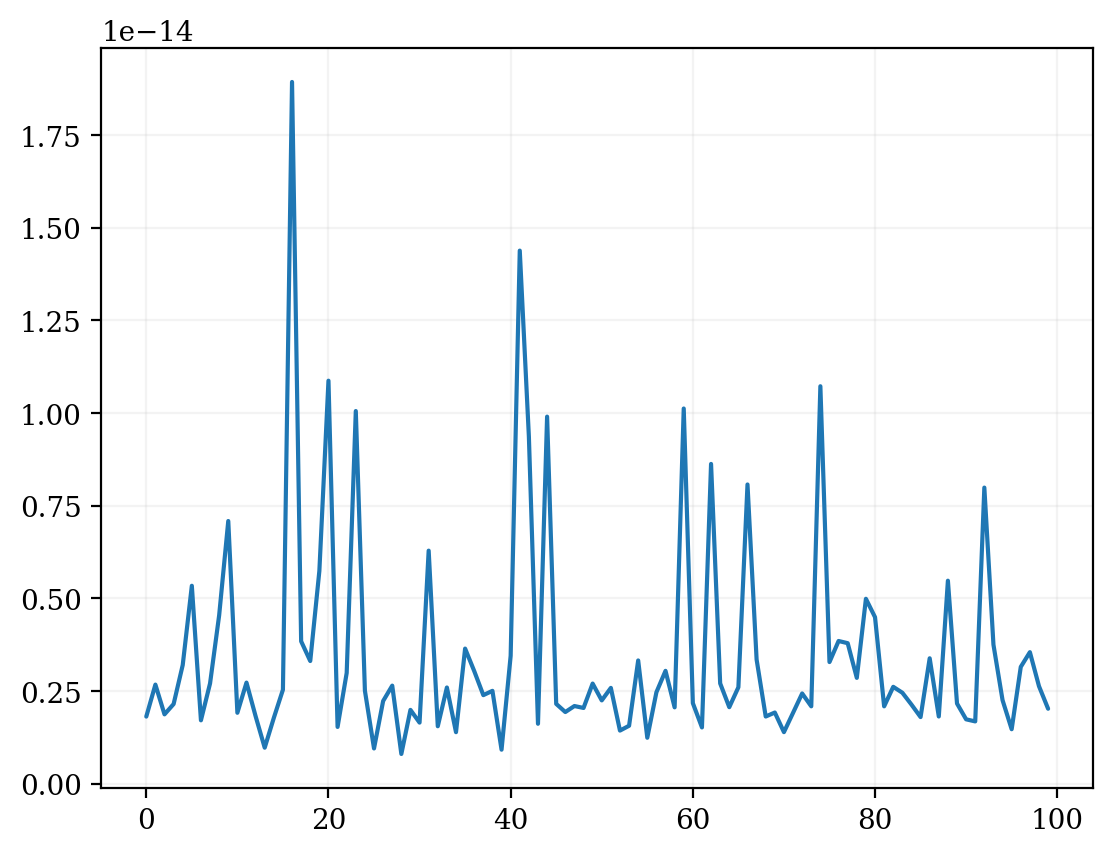

In [103]:
plt.plot(hc_ss[:,0,1,0])

In [ ]:
fig, ax = holo.plot.figax()

# Sensiticity curves
#ax.loglog(ng15_sc_gwb.freqs, ng15_sc_gwb.h_c, color='C3', label='Original NG15')
ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

# Flag to only label the single-source scatter once
labeled_single_sources = False
single_source_color = 'C2'  # choose any matplotlib color (C0–C9, or 'gray', etc.)

for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # Combined GWs from all binaries except `L` loudest
        bg = hc_bg[nr, :, rr]

        # Add in remaining loudest binaries (if any)
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))

        # Plot the single sources (same color for all)
        for ll in range(plot_num_loudest):
            if not labeled_single_sources:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color,
                    label='Loudest Single Sources'
                )
                labeled_single_sources = True
            else:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color
                )


# Axis setup and labels
plt.xlim(2e-9, 1e-7)
plt.ylim(1e-16,5e-12)
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title('NANOGrav Sensitivity to Single Sources')
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("dsa_ng20_ng15_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
fig, ax = holo.plot.figax()

# Sensiticity curves
#ax.loglog(ng15_sc_gwb.freqs, ng15_sc_gwb.h_c, color='C3', label='Original NG15')
ax.loglog(sliced_GWBSC.freqs, sliced_GWBSC.h_c, color='C1', label='15-year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs, ng20_sens.h_c, color='C0', label='NANOGrav 20-yr+DSA1650')

# Flag to only label the single-source scatter once
labeled_single_sources = False
single_source_color = 'C2'  # choose any matplotlib color (C0–C9, or 'gray', etc.)

for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # Combined GWs from all binaries except `L` loudest
        bg = hc_bg[nr, :, rr]

        # Add in remaining loudest binaries (if any)
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))

        # Plot the single sources (same color for all)
        for ll in range(plot_num_loudest):
            if not labeled_single_sources:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color,
                    label='Loudest Single Sources'
                )
                labeled_single_sources = True
            else:
                ax.scatter(
                    fobs_gw_cents,
                    hc_ss[nr, :, rr, ll],
                    s=10,
                    alpha=0.5,
                    color=single_source_color
                )


# Axis setup and labels
plt.xlim(2e-9, 1e-7)
plt.ylim(1e-16,5e-12)
# plt.ylim(3e-15,5e-12)
# plt.xlim(2e-10,1.7e-7)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title('NANOGrav Sensitivity to Single Sources')
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("dsa_ng20_ng15_sensitivity_comparison_cws.png", dpi=300, bbox_inches='tight')
plt.show()


### 3) Single source detection volume

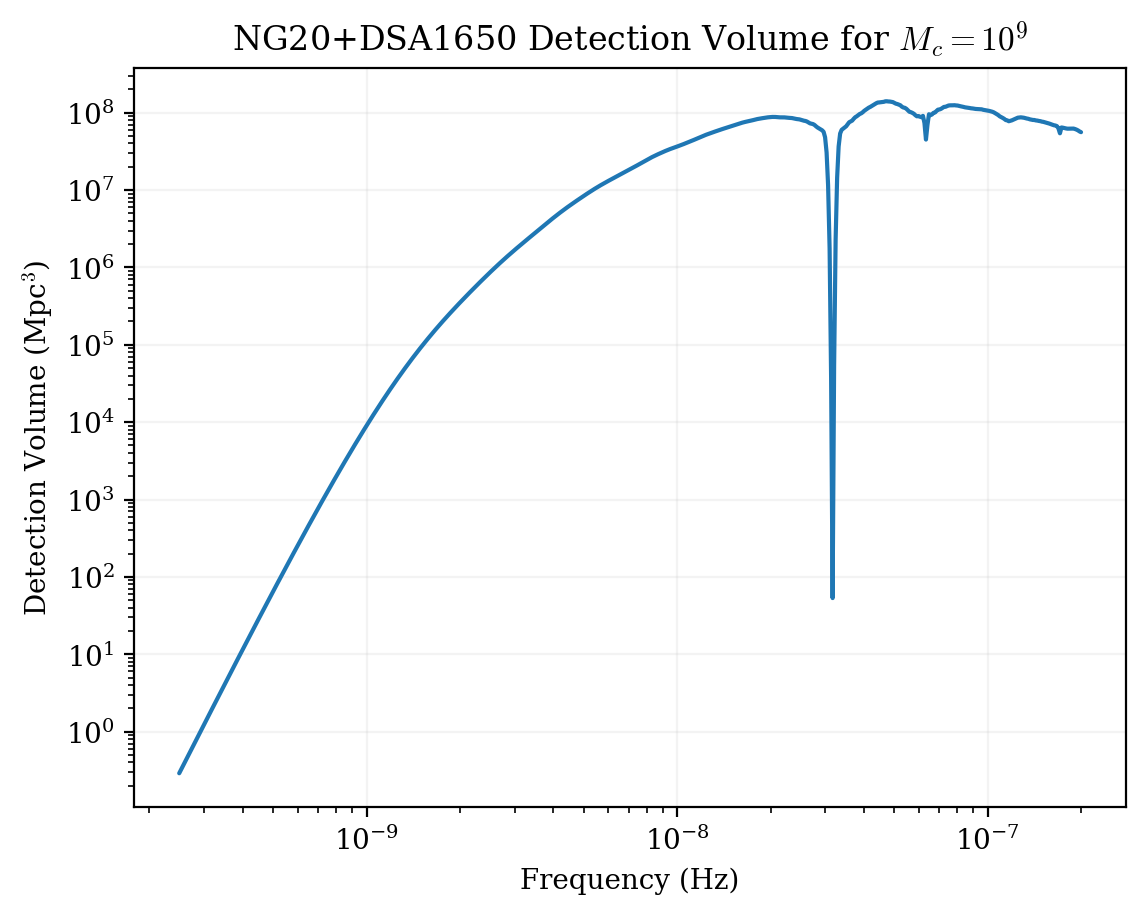

In [31]:
#plot skymap for hc
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)
SM_full_20=hsky.SkySensitivity(specs,theta_gw, phi_gw)
dv_full_20 = SM_full_20.calculate_detection_volume(f0=freqs, SNR_threshold=5, M_c=1e9)
plt.loglog(freqs,dv_full_20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Detection Volume (Mpc$^3$)')
plt.title('NG20+DSA1650 Detection Volume for $M_c=10^9$')
plt.savefig('dsa_ng20_detection_volume_mc1e9.png',dpi=300)
plt.show()

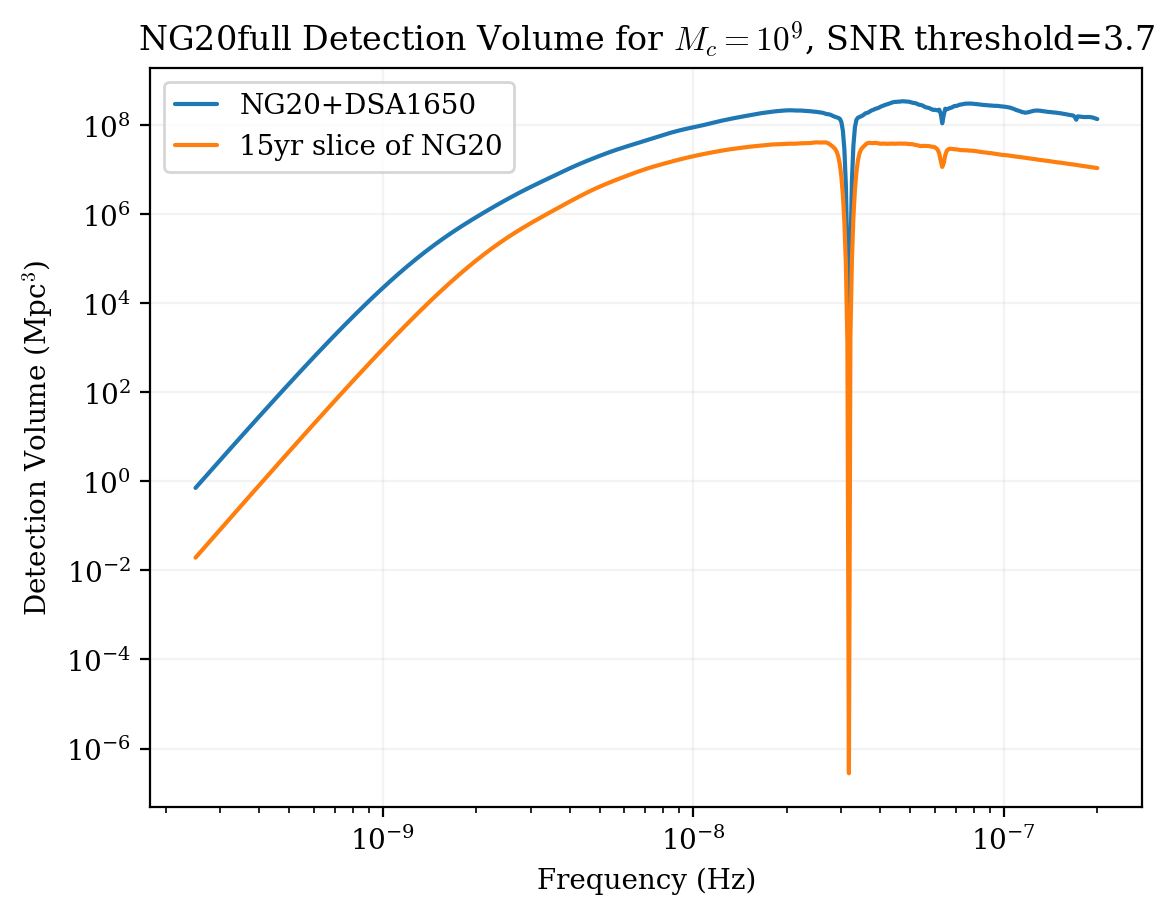

1/Tspan_DSA: 25.439316406405197
1.2464875815523325e-09


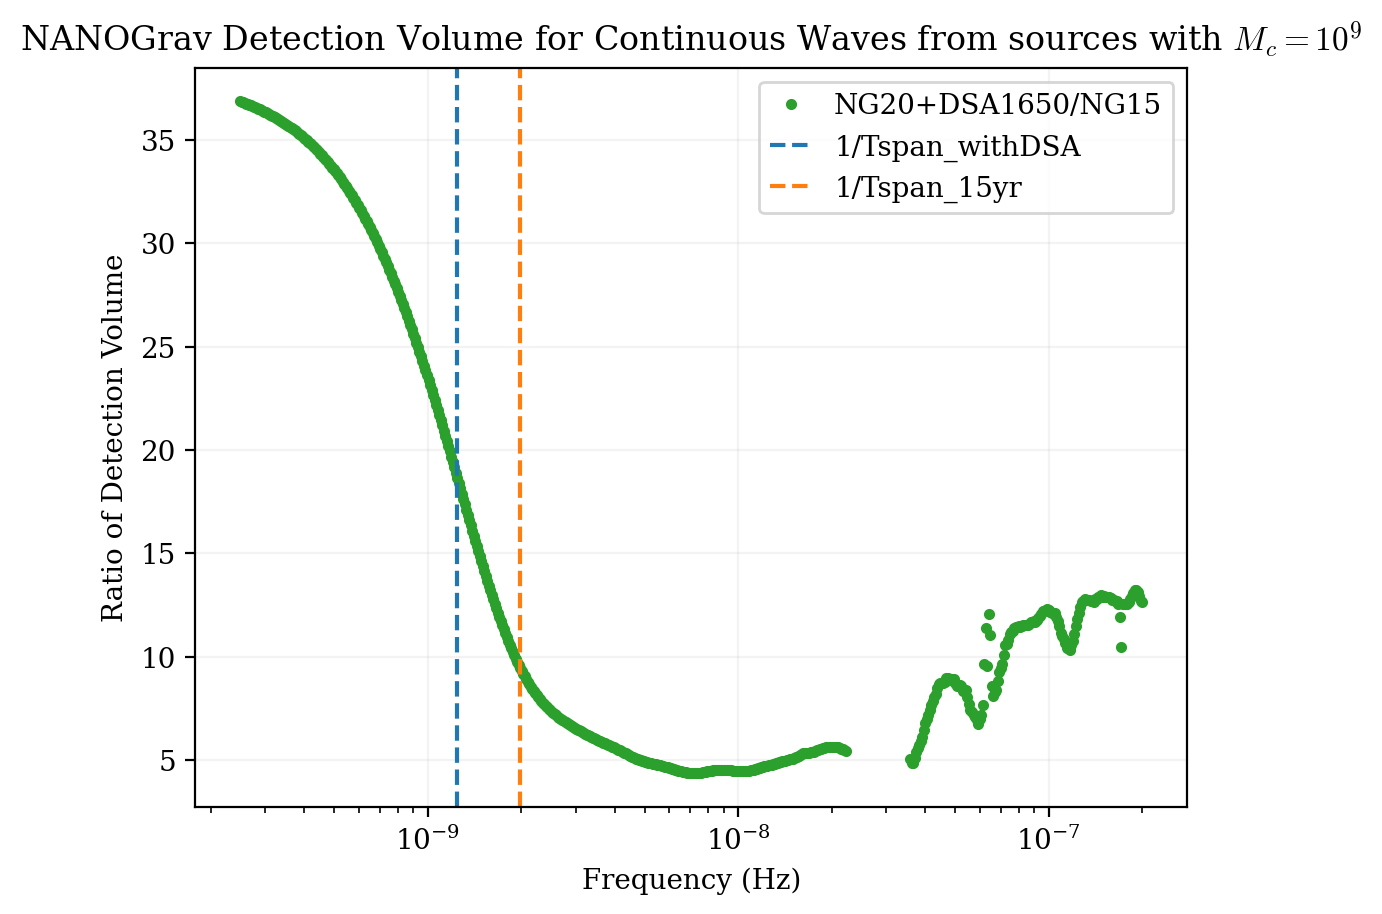

In [32]:
dv_full_20 = SM_full_20.calculate_detection_volume(f0=freqs, SNR_threshold=3.7, M_c=1e9)
SM_15yr_20=hsky.SkySensitivity(psr_spectra,theta_gw, phi_gw)
dv_15yr_20 = SM_15yr_20.calculate_detection_volume(f0=freqs, SNR_threshold=3.7, M_c=1e9)
plt.loglog(freqs,dv_full_20,label='NG20+DSA1650')
plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Detection Volume (Mpc$^3$)')
plt.title('NG20full Detection Volume for $M_c=10^9$, SNR threshold=3.7')
plt.legend()
plt.savefig('ng20full_detection_volume_comparison_mc1e9.png',dpi=300)
plt.show()

dv_ratio = np.array(dv_full_20)/np.array(dv_15yr_20)

#add frequency lines for 1/(15 years) and 1/(20 years)
f_dsa = 1/ng20_sens.Tspan
print('1/Tspan_DSA:', ng20_sens.Tspan/(365*86400))
print(f_dsa)
f_15 = 1/sliced_GWBSC.Tspan #tspan for the 15 year slice
#plt.plot(freqs,dv_ratio,label='Full NG20/15yr slice')
#plt.axvspan(1e-8, plt.xlim()[1], color='gray', alpha=0.2, label='White noise dominated frequencies')
fyr = 1/(365.25*24*3600)
mask = (freqs < 0.7 * fyr) | (freqs > 1.12 * fyr)
plt.plot(freqs[mask], dv_ratio[mask],'.',label='NG20+DSA1650/NG15',color='C2')
plt.axvline(f_dsa,linestyle='--',label='1/Tspan_withDSA',color='C0')
plt.axvline(f_15,linestyle='--',label='1/Tspan_15yr',color='C1')
plt.xscale('log')
#plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
#plt.xlim(1.3e-9,1e-7)
#plt.ylim(1,8)
#plt.grid(which='both')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio of Detection Volume')
plt.title('NANOGrav Detection Volume for Continuous Waves from sources with $M_c=10^9$')
plt.legend()
plt.savefig('dsa_ng20full_detection_volume_ratio_mc1e9_3sigma.png',dpi=300)
plt.show()



1/Tspan_DSA: 25.439316406405197
1.2464875815523325e-09


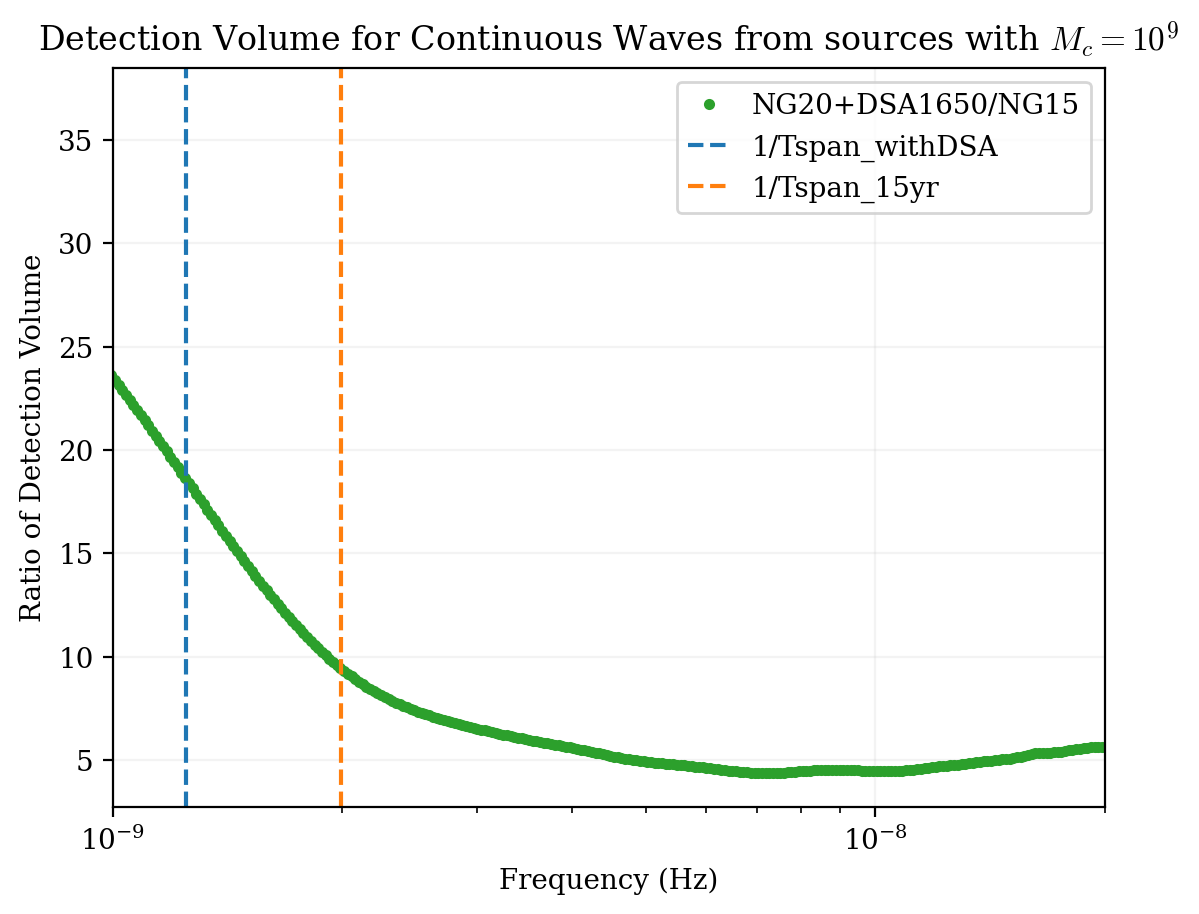

In [33]:
#add frequency lines for 1/(15 years) and 1/(20 years)
f_dsa = 1/ng20_sens.Tspan
print('1/Tspan_DSA:', ng20_sens.Tspan/(365*86400))
print(f_dsa)
f_15 = 1/sliced_GWBSC.Tspan #tspan for the 15 year slice
#plt.plot(freqs,dv_ratio,label='Full NG20/15yr slice')
#plt.axvspan(1e-8, plt.xlim()[1], color='gray', alpha=0.2, label='White noise dominated frequencies')
fyr = 1/(365.25*24*3600)
mask = (freqs < 0.7 * fyr) | (freqs > 1.12 * fyr)
plt.plot(freqs[mask], dv_ratio[mask],'.',label='NG20+DSA1650/NG15',color='C2')
plt.axvline(f_dsa,linestyle='--',label='1/Tspan_withDSA',color='C0')
plt.axvline(f_15,linestyle='--',label='1/Tspan_15yr',color='C1')
plt.xscale('log')
#plt.loglog(freqs,dv_15yr_20,label='15yr slice of NG20')
plt.xlim(1e-9,2e-8)
#plt.ylim(1,8)
#plt.grid(which='both')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio of Detection Volume')
plt.title('Detection Volume for Continuous Waves from sources with $M_c=10^9$')
plt.legend()
plt.savefig('dsa_ng20full_detection_volume_ratio_mc1e9_3sigma.png',dpi=300)
plt.show()

### 4) Single source detection probabilities - Dave's populations with 15-year frequency spacing

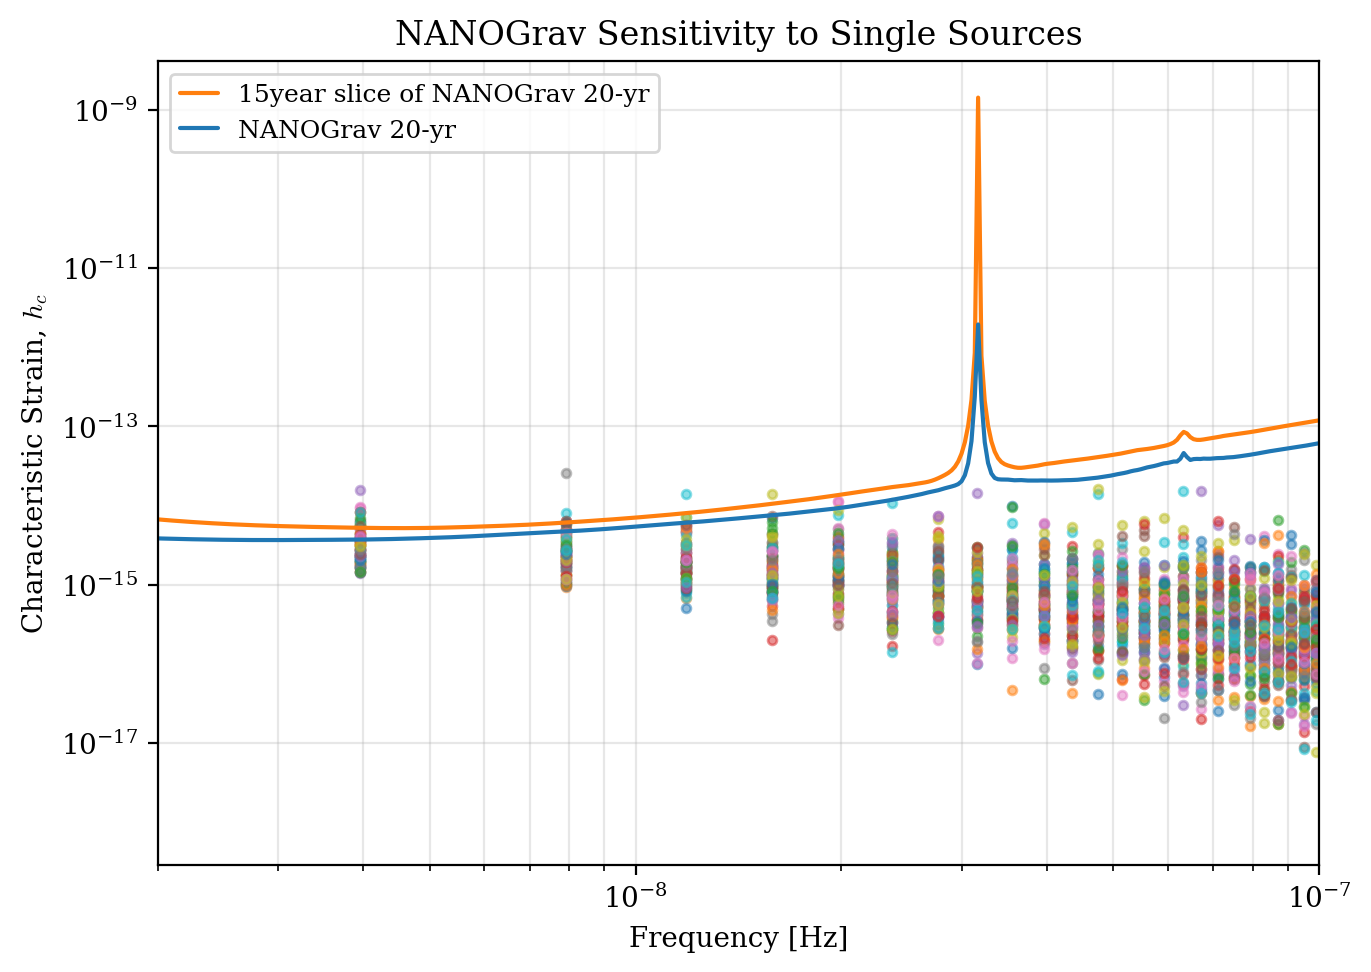

In [139]:
data = h5py.File('pop-draw-sims-15yr.h5', 'r') 
# Number of realizations to plot
plot_num_reals = 10
plot_num_params = 10
# Number of loudest-binaries-per-bin to plot
plot_num_loudest = 1

# ---- Load data

# Frequency bin edges, in units of [1/sec], for orbital frequencies
fobs_orb_edges = data["fobs_orb_edges"][0]  # Just need the first one, they're all the same
# convert to GW frequency centers (assuming circular orbits)
fobs_orb_cents = 0.5 * (fobs_orb_edges[1:] + fobs_orb_edges[:-1])
fobs_gw_cents = 2.0 * fobs_orb_cents #* YR

# Characteristic strains of the L loudest binaries in each of F frequency bins for each of R realizations
# shape: (NParReals, F, R, L)
hc_ss = data["hc_ss"]
npar_reals, nfreqs, nreals, nloudest = hc_ss.shape 
# Characteristic strain of all *other* binaries (i.e. All minus L)
# shape: (NParReals, F, R)
hc_bg = data["hc_bg"]

# can't plot more elements than we have in the data
plot_num_reals = np.minimum(plot_num_reals, nreals)
plot_num_params = np.minimum(plot_num_params, npar_reals)
plot_num_loudest = np.minimum(plot_num_loudest, nloudest)

# ---- Plot GW signals

fig, ax = holo.plot.figax()
for nr in range(plot_num_params):
    for rr in range(plot_num_reals):
        # this is the combined GWs from all binaries except `L` loudest in each frequency bin
        bg = hc_bg[nr, :, rr]
        # add back in the strains from the loudest binaries that we aren't plotting
        if nloudest > plot_num_loudest:
            fg = hc_ss[nr, :, rr, plot_num_loudest:]
            # Add in quadrature, summing over however many loudest binaries remain
            bg = np.sqrt(bg**2 + np.sum(fg**2, axis=-1))
         
        #(hh,) = ax.plot(fobs_gw_cents, bg, alpha=0.75)
        for ll in range(plot_num_loudest):
            ax.scatter(
                fobs_gw_cents, hc_ss[nr, :, rr, ll], s=10, alpha=0.5
            )
            
# Plot a -2/3 power-law of amplitude 1e-15 for reference
#hc_plaw = 1.0e-15 * np.power(fobs_gw_cents, -2.0 / 3.0)
#ax.plot(fobs_gw_cents, hc_plaw, "k--", alpha=0.5, lw=1.0)

#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,color='C3',label='Original NG15')
ax.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,color='C1',label='15year slice of NANOGrav 20-yr')
ax.loglog(ng20_sens.freqs,ng20_sens.h_c,color='C0',label='NANOGrav 20-yr')
#ax.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlim(2e-9,1e-7)
# ---- Labels, legend, and grid
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic Strain, $h_c$')
ax.set_title(
    'NANOGrav Sensitivity to Single Sources'#\n'
    #f'SNR={sliced_SNR:.2f}'
)
ax.grid(which='both', alpha=0.3)
ax.legend(loc='best', fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
#plt.show()
plt.savefig("ng20_ng15_sensitivity_comparison_cws_15year_freq_res.png", dpi=300, bbox_inches='tight')
plt.show()

In [140]:
SM_full_20.detection_prob??

Signature:
SM_full_20.detection_prob(
    F_thresh,
    snr=None,
    Npsrs=None,
    ave=None,
    prob_kwargs={'h0': None, 'fidx': None},
)
Source:   
    def detection_prob(self, F_thresh, snr=None, Npsrs=None, ave=None, prob_kwargs={'h0':None,'fidx':None}):
        '''
        Detection probability of the F-statistic. See Rosado et al. 2015 `[3]` equation 32.
        Use None for the Fe and the number of pulsars for the Fp stat.

       Parameters
        ----------
        F_thresh : float,array
            F-statistic threshold

        snr : float, optional
            Signal to noise ratio for a given single source.

        Npsrs : string, optional
            Number of pulsars in the array for using the Fp statistic.
            Use None for the Fe statistic.

        ave : string, optional -- choose from ['none','snr','prob']
            Point at which angle averaging happens for the F-statistic.
            See appendix of Baier et al. 2024 `[2]` for details.
              

In [ ]:
for fi in range(len(fobs_gw_cents)):
    fidx = np.argmin(np.abs(ng20_sens.freqs - fobs_gw_cents[fi]))
    print(f"fi={fi}, fobs_gw_cents={fobs_gw_cents[fi]}, fidx={fidx}")
dp_full = SM_full_20.detection_prob(F_thresh = 3.7, snr=5, ave='prob', prob_kwargs={'h0': 4e-15, 'fidx': , 'int_method' : 'dblquad'})#, Npsrs=None, ave=None, prob_kwargs={'h0':None,'fidx':None})

In [151]:
SM_full_20.h_c.shape

(600, 768)

In [ ]:
SM_full_20.detection_prob??

Signature:
SM_full_20.detection_prob(
    F_thresh,
    snr=None,
    Npsrs=None,
    ave=None,
    prob_kwargs={'h0': None, 'fidx': None},
)
Source:   
    def detection_prob(self, F_thresh, snr=None, Npsrs=None, ave=None, prob_kwargs={'h0':None,'fidx':None}):
        '''
        Detection probability of the F-statistic. See Rosado et al. 2015 `[3]` equation 32.
        Use None for the Fe and the number of pulsars for the Fp stat.

       Parameters
        ----------
        F_thresh : float,array
            F-statistic threshold

        snr : float, optional
            Signal to noise ratio for a given single source.

        Npsrs : string, optional
            Number of pulsars in the array for using the Fp statistic.
            Use None for the Fe statistic.

        ave : string, optional -- choose from ['none','snr','prob']
            Point at which angle averaging happens for the F-statistic.
            See appendix of Baier et al. 2024 `[2]` for details.
              